# ML lab 09: SVMs

In [1]:
# Uncomment to upgrade packages
#!pip3 install pandas --upgrade --user --quiet
#!pip3 install numpy --upgrade --user --quiet
#!pip3 install statsmodels --upgrade --user --quiet
#!pip3 install scipy --upgrade --user --quiet
#!pip3 install scikit-learn --upgrade --user --quiet
#!pip3 install graphviz --upgrade --user --quiet
#!pip3 install dython  --upgrade --user --quiet


In [2]:
import warnings
warnings.filterwarnings('ignore')

from time import time
from datetime import timedelta

import pandas as pd
import seaborn as sns
import numpy as np

from dython.nominal import associations
from dython.nominal import correlation_ratio
from dython.nominal import cramers_v

from scipy.stats import chi2_contingency 
from scipy.stats import pearsonr 

from sklearn.metrics import r2_score, mean_squared_error, median_absolute_error, mean_absolute_error
from sklearn.preprocessing import minmax_scale

from sklearn.svm import LinearSVR, SVR, SVC
from sklearn.neighbors import KNeighborsRegressor

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

from matplotlib import pyplot as plt 

## Auxiliar functions

On this notebook we are going to use the next auxiliar functions: 
* `load_and_split_life_expectancy_data`: This will help us split our data taking its temporal component into acount. 
* `compute_metrics`: will help us compute the specific metrics that we will be using.

In [3]:
def load_and_split_life_expectancy_data():
    life_expectancy_data = pd.read_csv('Life_Expectancy_Data.csv')
    life_expectancy_data.columns = [
        c.lower().strip().replace(' ', '_').replace('/',
                                                    '_').replace('-', '_')
        for c in life_expectancy_data.columns
    ]
    X = life_expectancy_data.loc[:, life_expectancy_data.
                                 columns != 'life_expectancy']
    y = life_expectancy_data['life_expectancy']

    # Transform categorical columns type to avoid problems when transforming to dummies
    categorical_columns = ['country', 'status']
    for column in categorical_columns:
        X.loc[:, column] = X.loc[:, column].astype('category')

    test_index = (X['year'] >= 2013)  # 2013 2014 2015
    val_index = (X['year'] >= 2010) & (X['year'] < 2013)  # 2010 2011 2012
    train_index = ~(test_index | val_index)  # < 2010

    X_train = X[train_index]
    y_train = y[train_index]

    X_val = X[val_index]
    y_val = y[val_index]

    X_test = X[test_index]
    y_test = y[test_index]

    return X_train, y_train, X_val, y_val, X_test, y_test

def comptue_metrics(y_pred, y_real):
    r2 = r2_score(y_pred,y_real)
    mse = mean_squared_error(y_pred, y_real)
    median_abs_e = median_absolute_error(y_pred, y_real)
    mean_abs_e = mean_absolute_error(y_pred, y_real)
    return [r2, mse, median_abs_e, mean_abs_e]

## SECTION 1: Life expentancy data

In this lab we are going to use the Life expectancy dataset again. Last time we treated the year variable as a categorical variable, which did not take into account possible temporal relationships between the samples (like seasonality). This way, we risked obtaining over-optimistic results. This time we will treat it as a temporal variable and our decisions will be affected by it. 

### Metrics

We are going to use the next regression metrics:

**MSE** 

$$MSE(t,y) = \frac{1}{N} \sum_{i=1}^N (t - y(x;w))^2$$

Where t is the real value of the target and y(x;w) is our prediction. MSE is comonly used while training the models. You need to be carefull if you want to use it as a metric because it depends strongly of the range of the target. Best value is 0. 

**R2**
$$norm\_MSE(t,y) = \frac {MSE(t,y)}{s^2(t)} \Rightarrow R2 = (1 - norm\_MSE(t,y))$$ 

Where t is the real value of the target and y(x;w) is our prediction and $s^2$ is the unbiesed variance ($s^2(t) = \frac{n}{n-1}\sigma^2(t)$). This metric represents the target variability explained by the model. It will always be less than one and it is the most used metric on regression problems. Can be affected by having a lot of variables. Best value is 1.

**median_absolute_error**  


$$MedAE(t,y) = median(|t_1 - y(x;w)_1|,...., |t_n - y(x;w)_n| )$$

Where t is the real value of the target and y(x;w) is our prediction. Similar to MSE is scale dependent but it is robuts to outliers.

**mean_absolute_error**


$$MAE(t,y) = \frac{1}{N} \sum_{i=1}^N | t - y(x;w)| ^2$$

Where t is the real value of the target and y(x;w) is our prediction. Similar to MSE is scale dependent. 

In [4]:
life_expectancy_data = pd.read_csv('Life_Expectancy_Data.csv')
life_expectancy_data.columns = [c.lower().strip().replace(' ','_').replace('/','_').replace('-','_') for c in life_expectancy_data.columns] 
life_expectancy_data.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


If we check the number of samples of each year we can see that there are almost the same. 

In [5]:
life_expectancy_data['year'].value_counts()

year
2013    193
2015    183
2014    183
2012    183
2011    183
2010    183
2009    183
2008    183
2007    183
2006    183
2005    183
2004    183
2003    183
2002    183
2001    183
2000    183
Name: count, dtype: int64

In [6]:
life_expectancy_data['country'] = life_expectancy_data['country'].astype('category')
life_expectancy_data['status'] = life_expectancy_data['status'].astype('category')

If we where dealing with this problem in the real life we would probably want to predict the results of the next/next years based on the data collected until now. 

To simulate this we will use the last 3 years for test, the last 3 years after them for validation and the rest of the data as training. 

In [7]:
#X = life_expectancy_data.loc[:,life_expectancy_data.columns != 'life_expectancy']
#y = life_expectancy_data['life_expectancy']
    
test_index = (life_expectancy_data['year']>=2013) # 2013 2014 2015
val_index = (life_expectancy_data['year']>=2010) & (life_expectancy_data['year']<2013) # 2010 2011 2012
train_index = ~(test_index | val_index) # < 2010

Now let's see how this decision affects our target. Does the target distribution change over time? 

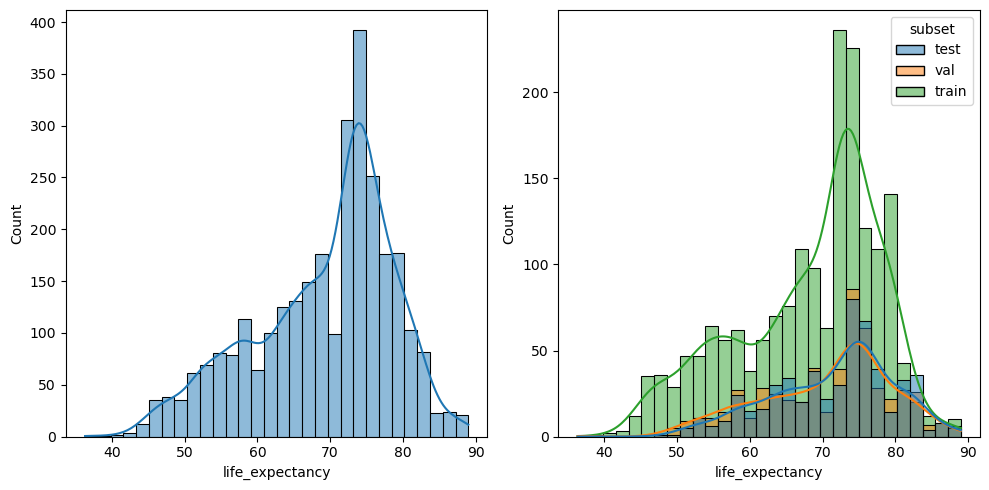

In [8]:
import matplotlib.pyplot as plt

life_expectancy_data.loc[train_index,'subset'] = 'train'
life_expectancy_data.loc[val_index,'subset'] = 'val' 
life_expectancy_data.loc[test_index,'subset'] = 'test' 

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(x='life_expectancy',data=life_expectancy_data, ax=axs[0], kde=True)
sns.histplot(x='life_expectancy',data=life_expectancy_data,hue='subset', fill=True, ax=axs[1], kde=True)
plt.tight_layout()
plt.show()

Seeing this plot we can see that the distribution doesn't seem to change a lot sepparating by years. This could imply that we have chosen a test an validation sets that are representative with respect to our data and that the behaviour of our target does not change significantly between years.

### Correlations

Now, before starting training models we are going to see the correlations between our variables. 

If we use pandas correlation method it will compute the pearson correlation betweeen the numerical variables and will completely ignore the categorical ones. 


With our data we are going to focus on the correlations with the target to see if there are direct relationships between the predictive variables and it. We might also check for strong correlations between predictive variables as that could mean that any of the variables could be redundant.

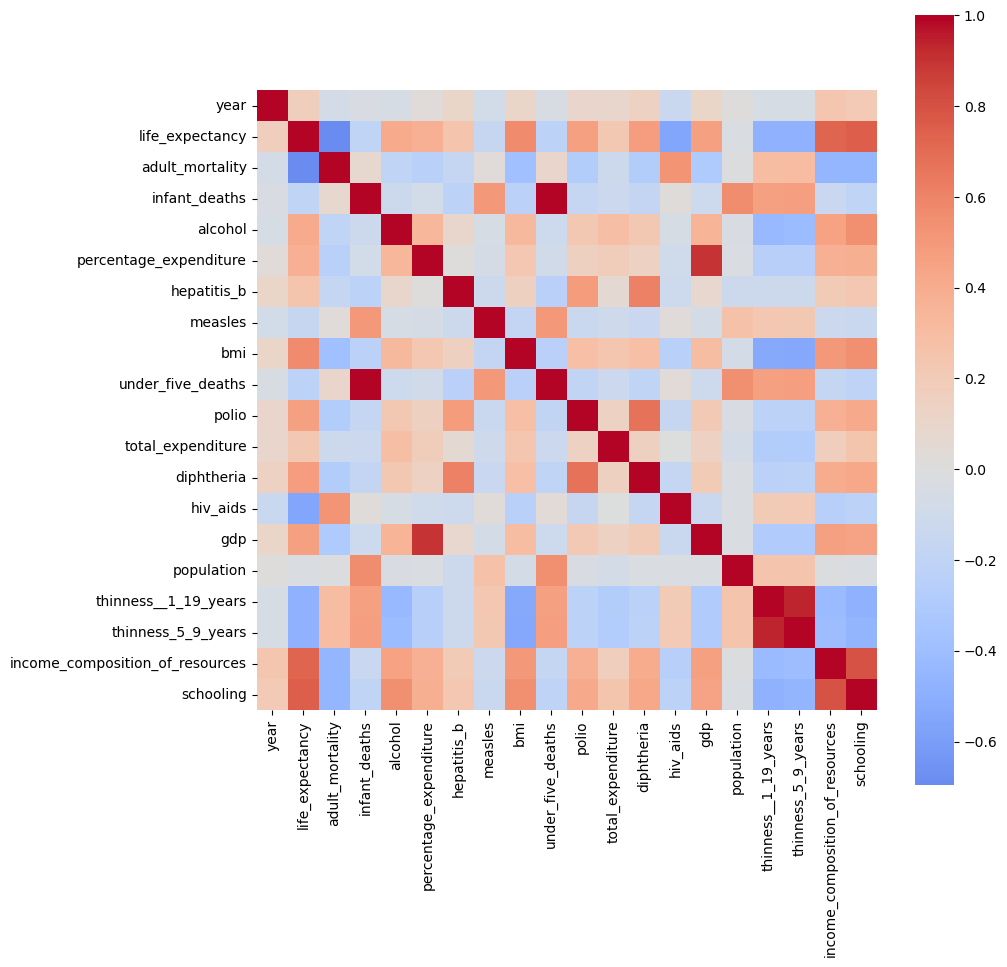

In [9]:
corr = life_expectancy_data[life_expectancy_data.select_dtypes([np.number]).columns].corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corr, center=0, square=True, cbar=True, cmap='coolwarm');

Now what can we do if we want to calculate the correlation between categorical variables or categorical and numerical? 

There are different methods:
* Pearson's R for continuous-continuous cases
* Correlation Ratio for categorical-continuous cases
* Cramer's V or Theil's U for categorical-categorical cases

Library `dython` will detect automatically the type of the variables (as long as they have the proper data type for pandas).

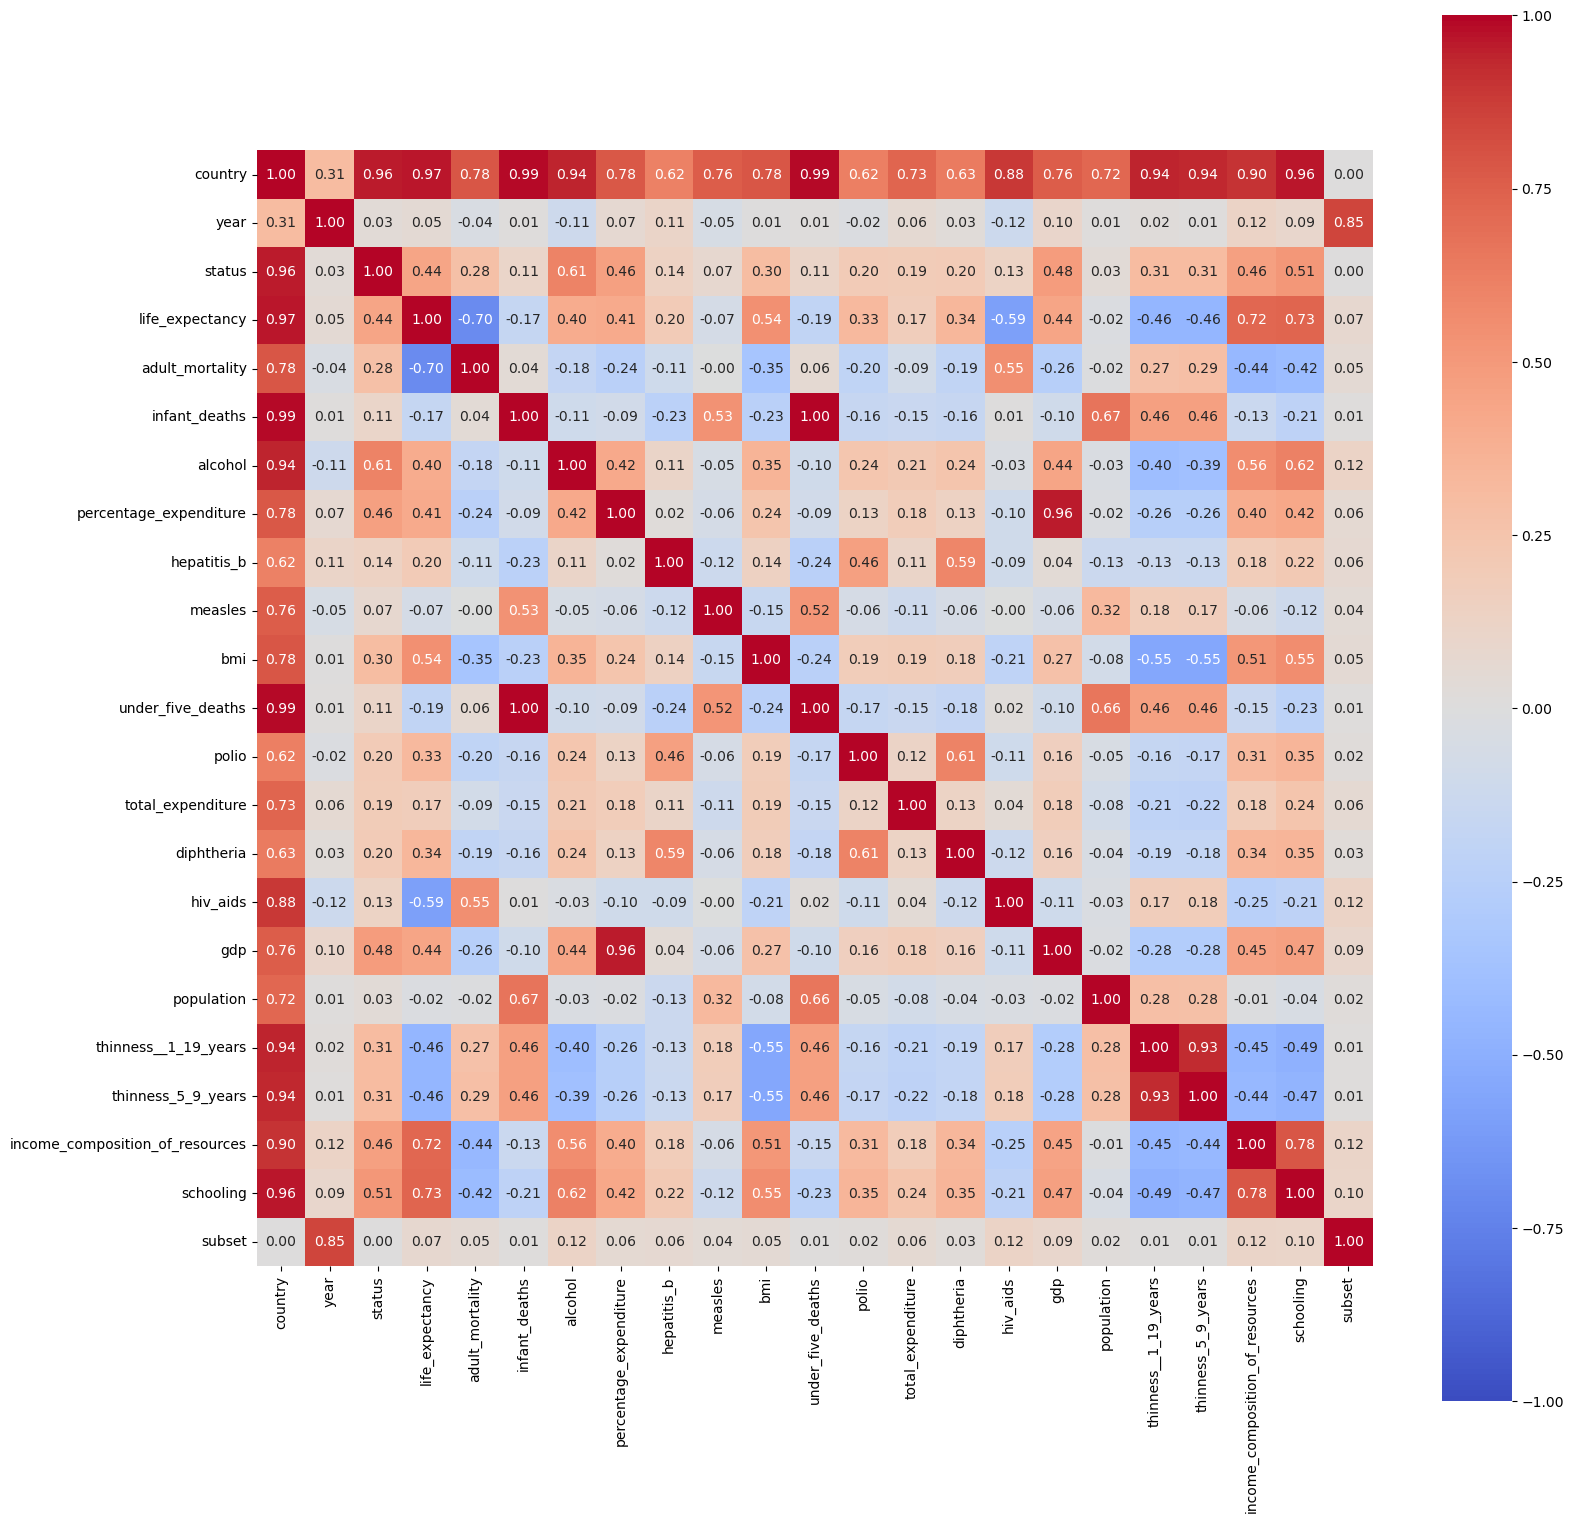

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling,subset
country,1.000000,0.310833,0.959407,0.966681,0.783413,0.986301,0.937886,0.775116,0.615379,0.762242,...,0.730216,0.633379,0.884859,0.763206,0.720220,0.940538,0.936497,0.901681,0.963434,0.000000
year,0.310833,1.000000,0.034138,0.050771,-0.037092,0.008029,-0.113365,0.069553,0.114897,-0.053822,...,0.059493,0.029641,-0.123405,0.096421,0.012567,0.019757,0.014122,0.122892,0.088732,0.846140
status,0.959407,0.034138,1.000000,0.442798,0.278173,0.108757,0.607782,0.461688,0.140351,0.071963,...,0.192538,0.201654,0.129555,0.484801,0.034790,0.308005,0.307279,0.463615,0.512543,0.000000
life_expectancy,0.966681,0.050771,0.442798,1.000000,-0.702523,-0.169074,0.402718,0.409631,0.199935,-0.068881,...,0.174718,0.341331,-0.592236,0.441322,-0.022305,-0.457838,-0.457508,0.721083,0.727630,0.071799
adult_mortality,0.783413,-0.037092,0.278173,-0.702523,1.000000,0.042450,-0.175535,-0.237610,-0.105225,-0.003967,...,-0.085227,-0.191429,0.550691,-0.255035,-0.015012,0.272230,0.286723,-0.442203,-0.421171,0.048496
infant_deaths,0.986301,0.008029,0.108757,-0.169074,0.042450,1.000000,-0.106217,-0.090765,-0.231769,0.532680,...,-0.146951,-0.161871,0.007712,-0.098092,0.671758,0.463415,0.461908,-0.134754,-0.214372,0.013118
alcohol,0.937886,-0.113365,0.607782,0.402718,-0.175535,-0.106217,1.000000,0.417047,0.109889,-0.050110,...,0.214885,0.242951,-0.027113,0.443433,-0.028880,-0.403755,-0.386208,0.561074,0.616975,0.124987
percentage_expenditure,0.775116,0.069553,0.461688,0.409631,-0.237610,-0.090765,0.417047,1.000000,0.016760,-0.063071,...,0.183872,0.134813,-0.095085,0.959299,-0.016792,-0.255035,-0.255635,0.402170,0.422088,0.060960
hepatitis_b,0.615379,0.114897,0.140351,0.199935,-0.105225,-0.231769,0.109889,0.016760,1.000000,-0.124800,...,0.113327,0.588990,-0.094802,0.041850,-0.129723,-0.129406,-0.133251,0.184921,0.215182,0.064088
measles,0.762242,-0.053822,0.071963,-0.068881,-0.003967,0.532680,-0.050110,-0.063071,-0.124800,1.000000,...,-0.113583,-0.058606,-0.003522,-0.064768,0.321946,0.180642,0.174946,-0.058277,-0.115660,0.043464


In [10]:
output = associations(life_expectancy_data, nan_strategy='drop_samples', figsize=(18,18), cmap='coolwarm')

correlation = output['corr']
ax = output['ax']

correlation

It looks like categorical variables are important for predicting the target. 

In [11]:
num_cols = list(life_expectancy_data.select_dtypes([np.number]).columns)
cat_cols = list(np.setdiff1d(life_expectancy_data.columns, num_cols))
print(f'nums: {num_cols}')
print(f'cat: {cat_cols}')

categorical_with_target = ['country', 'status', 'life_expectancy']
correlation.loc[ categorical_with_target, categorical_with_target ]

nums: ['year', 'life_expectancy', 'adult_mortality', 'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi', 'under_five_deaths', 'polio', 'total_expenditure', 'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness__1_19_years', 'thinness_5_9_years', 'income_composition_of_resources', 'schooling']
cat: ['country', 'status', 'subset']


,country,status,life_expectancy
country,1.000000,0.959407,0.966681
status,0.959407,1.000000,0.442798
life_expectancy,0.966681,0.442798,1.000000


In [12]:
life_expectancy_data['country'].nunique()

193

As the country variable shows a strong correlation with life expectancy we are interested on adding it to our model but if we do a one-hot-encoding we might end with a course of dimensionality as last time we tried. 133 countries imply 133 new sparse variables, which could turn out in a very slow mess.

First we will try to predict without these variables and then we will see a new approach to handle mixed data.

### First preprocessing: Ignore categorical variables

In our first approach we will use the minimum preprocessing of last time but this time with scaling. This scaling is important because the models (KNNR and SVR) we are using in this lab are strongly affected by range difference by the variables. 

In [13]:
X_train, y_train, X_val, y_val, X_test, y_test = load_and_split_life_expectancy_data()

def minimum_preprocessing(X, y):
    print('Original shape:{}'.format(X.shape))
    # We kill categorical columns
    cat_cols = ['status', 'country']
    X=X.drop(columns=cat_cols)
    print('Droped: {}'.format(cat_cols))
    # We remove missing values
    X=X.dropna()
    y=y[X.index]
    # Normalize
    X = minmax_scale(X)
    print('New shape:{}'.format(X.shape))
    return X, y

X_train, y_train = minimum_preprocessing(X_train,y_train)
X_val, y_val = minimum_preprocessing(X_val,y_val)
X_test, y_test = minimum_preprocessing(X_test,y_test)

# We also instantiate our results dataframe
results = pd.DataFrame(columns=['Kernel', 'C', 'epsilon', 'R2', 'MSE', 'median_absolute_error', 'mean_absolute_error'])

Original shape:(1830, 21)
Droped: ['status', 'country']
New shape:(999, 19)
Original shape:(549, 21)
Droped: ['status', 'country']
New shape:(387, 19)
Original shape:(559, 21)
Droped: ['status', 'country']
New shape:(263, 19)


### Baseline: KNN

We will take as our baseline the KNN regressor model with the default parameters. This model can be a good baseline for comparing with SVR because it is simple, fast, interpretable and distance based(like SVM). 

We have seen in our correlation study that there are direct correlations between our predictive variables and our target. That implies that the we should be able to predict it to some term using a simple model. So, if we weren't able to predict something using this model it could be a sign that there is something wrong with our preprocessing.

Finding problems in pre-processing or in our data is a lot faster if you use a baseline. With complex models you could think that there is some problem with your hyperparameters and spend hours tuning them until you find that the problem was on other step of your pipeline.

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
KNN,-,-,-,0.811983,13.925304,2.12,2.886305


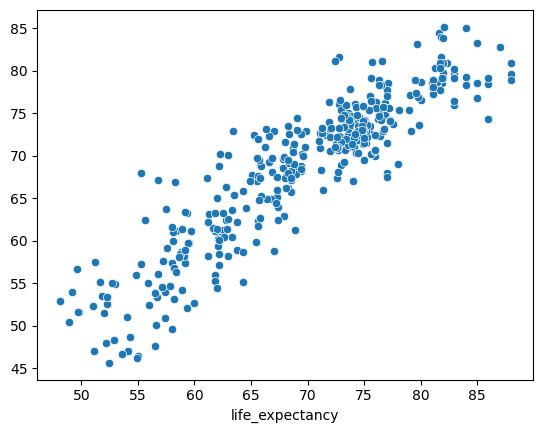

In [14]:
knn = KNeighborsRegressor()

knn.fit(X_train,y_train)
y_pred = knn.predict(X_val)

results.loc['KNN', :] = ['-', '-', '-'] + comptue_metrics(y_pred,y_val)

sns.scatterplot(x=y_val, y=y_pred)
results

Cheking our metrics and the scaterplot of the predicted vs real validation values of the target, we can see that knn is already doing a good job with its default parameters. This is a good sign, as we had already seen on our data analyisis that predicting this target should not be extreamly dificult for a model. 

### SVM Lineal

The basic idea of the SVM regressor is to use a limited number of the training samples (suport vectors) to predict. The prediction will be a linear combination of the suport vectors (similar to linear regression). 

The powerful part of this model is that using the kernel trick you can modify the original space to fit non-linear functions.

This model has the next hyperparameters: 
* $\epsilon$ : All errors lower to epsilon will be taken as zero in the loss function. 
* $C$ : Regularization parameter. It will avoid the model to use too many suport vectors. 
* Kernel: The function that will modify the original space.

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
LinearSVR-default,linear,1,0,0.812529,15.038759,2.174869,2.972721
KNN,-,-,-,0.811983,13.925304,2.12,2.886305


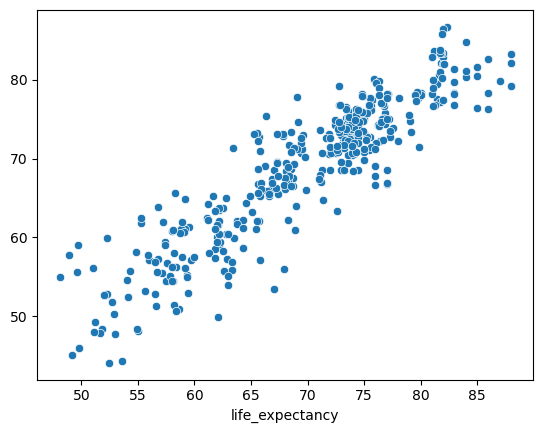

In [15]:
svm = LinearSVR()

svm.fit(X_train,y_train)
y_pred = svm.predict(X_val)
results.loc['LinearSVR-default', :] = ['linear',1,0] + comptue_metrics(y_pred,y_val)

sns.scatterplot(x=y_val, y=y_pred)

results.sort_values(by='R2', ascending=False)

If we train our dummy SVR, we obtain slighly better results than with the KNN. That is a good sign. Let's tune the hyperparameters to see if we can improve more our results.

For comparing the models we will use our validation partition.

In [16]:
cv_results = pd.DataFrame(columns=['Kernel', 'C', 'epsilon', 'R2', 'MSE', 'median_absolute_error', 'mean_absolute_error'])

Cs = [10,20,30,40,50,60]
epsilons = [0.001,0.0001,0.00001,0.000001,0]
for c in Cs:
    for epsilon in epsilons:
        svm = SVR(kernel='linear', C=c,epsilon=epsilon)
        svm.fit(X_train,y_train)
        y_pred = svm.predict(X_val)
        cv_results.loc['LinearSVR-{}-{}'.format(c,epsilon), :] = ['linear', c, epsilon] + comptue_metrics(y_pred,y_val)
        
best = cv_results.sort_values(by='R2',ascending=False).iloc[0,:]
results.loc['LinearSVR-best',:] = best

The linear svr is a __super fast__ model. For this reason we can try a lot of hyperparameters to see which ones are the better fit to our data.

Our validation results show that the hyperparameters are not having a strong effect on our results. 
The best configuration is `C=60 epsilon=0 R2=0.815502`	

In [17]:
cv_results.sort_values(by='R2', ascending=False)

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
LinearSVR-60-0,linear,60,0,0.815502,15.245514,2.352258,3.01427
LinearSVR-60-1e-05,linear,60,0.00001,0.815501,15.245609,2.352284,3.014279
LinearSVR-60-0.001,linear,60,0.001,0.815501,15.241314,2.353671,3.01378
LinearSVR-60-1e-06,linear,60,0.000001,0.815499,15.245622,2.352395,3.01428
LinearSVR-60-0.0001,linear,60,0.0001,0.815497,15.24555,2.35245,3.014266
LinearSVR-50-1e-05,linear,50,0.00001,0.815049,15.247674,2.354793,3.013874
LinearSVR-50-0,linear,50,0,0.815049,15.247723,2.355197,3.013884
LinearSVR-50-1e-06,linear,50,0.000001,0.815049,15.247758,2.354456,3.013889
LinearSVR-50-0.0001,linear,50,0.0001,0.815048,15.248046,2.354712,3.01392
LinearSVR-50-0.001,linear,50,0.001,0.815038,15.247405,2.353158,3.013813


Now we can compare the best LinearSVR result with the other models.

In [18]:
results.sort_values(by='R2', ascending=False)

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
LinearSVR-best,linear,60,0,0.815502,15.245514,2.352258,3.01427
LinearSVR-default,linear,1,0,0.812529,15.038759,2.174869,2.972721
KNN,-,-,-,0.811983,13.925304,2.12,2.886305


We can see that hyperparameters are not affecting strongly the results. Let's try with more complex kernels.

### Non-linear SVR

We obtain a non-linear SVR by applying a non-linear kernel to our data. In sklearn we have available RBF, Sigmoid and Polynomial kernels. 


#### Radial Basis Function

This kernel is a bit more complex. Lets see how handles the data with the default values.

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
LinearSVR-best,linear,60,0,0.815502,15.245514,2.352258,3.01427
LinearSVR-default,linear,1,0,0.812529,15.038759,2.174869,2.972721
KNN,-,-,-,0.811983,13.925304,2.12,2.886305
RBF-SVR-default,RBF,1,0,0.772741,13.466168,2.089179,2.818085


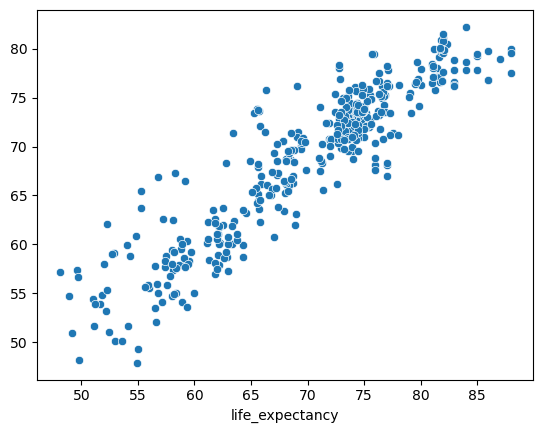

In [19]:
svr = SVR(kernel='rbf')
svr.fit(X_train,y_train)
y_pred = svr.predict(X_val)

results.loc['RBF-SVR-default', :] = ['RBF',1,0]+ comptue_metrics(y_pred,y_val)

sns.scatterplot(x=y_val, y=y_pred)
results.sort_values(by='R2', ascending=False)

It has a worse result than the Linear kernel. 
Let's see how tuning the hyperparameters affects the model performance. This time we will try less values because it is a slower model.

In [20]:
cv_results_rbf = pd.DataFrame(columns=['Kernel', 'C', 'epsilon', 'R2', 'MSE', 'median_absolute_error', 'mean_absolute_error'])

Cs = [10,20,30,40,50,60]
epsilons = [0.001,0.0001,0.00001,0.000001,0]
for c in Cs:
    for epsilon in epsilons:
        svm = SVR(kernel='rbf', C=c,epsilon=epsilon)
        svm.fit(X_train,y_train)
        y_pred = svm.predict(X_val)
        cv_results_rbf.loc['RBFSVR-{}-{}'.format(c,epsilon), :] = ['RBF', c, epsilon] + comptue_metrics(y_pred,y_val)
        
best = cv_results_rbf.sort_values(by='R2',ascending=False).iloc[0,:]
results.loc['RBFSVR-best',:] = best


cv_results_rbf

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
RBFSVR-10-0.001,RBF,10,0.001,0.841301,11.554958,1.914849,2.600394
RBFSVR-10-0.0001,RBF,10,0.0001,0.84129,11.555779,1.915313,2.600444
RBFSVR-10-1e-05,RBF,10,0.00001,0.84129,11.555782,1.914855,2.600428
RBFSVR-10-1e-06,RBF,10,0.000001,0.841286,11.555967,1.915017,2.600448
RBFSVR-10-0,RBF,10,0,0.841291,11.555973,1.915242,2.600453
RBFSVR-20-0.001,RBF,20,0.001,0.848911,11.504379,1.991328,2.615311
RBFSVR-20-0.0001,RBF,20,0.0001,0.848901,11.50542,1.995684,2.615484
RBFSVR-20-1e-05,RBF,20,0.00001,0.848905,11.505358,1.996095,2.615473
RBFSVR-20-1e-06,RBF,20,0.000001,0.8489,11.505297,1.996434,2.615483
RBFSVR-20-0,RBF,20,0,0.848897,11.50577,1.996454,2.615554


This time the hyperparameters have a stronger effect. This means that with bad hyperparameters we could obtain a very bad model while with the correct ones we could surpass the performance of simpler models. 

In [21]:
results.sort_values(by='R2', ascending=False)

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
RBFSVR-best,RBF,50,0.00001,0.852333,11.763404,2.038311,2.679041
LinearSVR-best,linear,60,0,0.815502,15.245514,2.352258,3.01427
LinearSVR-default,linear,1,0,0.812529,15.038759,2.174869,2.972721
KNN,-,-,-,0.811983,13.925304,2.12,2.886305
RBF-SVR-default,RBF,1,0,0.772741,13.466168,2.089179,2.818085


#### Sigmoid

Another non-linear kernel. This one uses the hyperbolic tangent as non-linearity. 

It is not looking good by its default results.

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
RBFSVR-best,RBF,50,0.00001,0.852333,11.763404,2.038311,2.679041
LinearSVR-best,linear,60,0,0.815502,15.245514,2.352258,3.01427
LinearSVR-default,linear,1,0,0.812529,15.038759,2.174869,2.972721
KNN,-,-,-,0.811983,13.925304,2.12,2.886305
RBF-SVR-default,RBF,1,0,0.772741,13.466168,2.089179,2.818085
SigmoidSVR-default,Sigmoid,1,0,-1.496859,179.074224,10.629716,11.235336


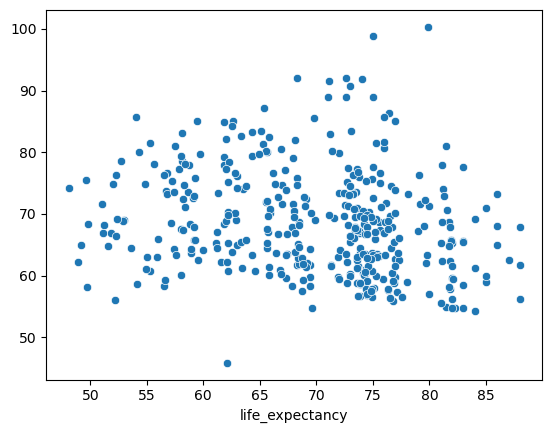

In [22]:
svr = SVR(kernel='sigmoid')

svr.fit(X_train,y_train)
y_pred = svr.predict(X_val)
results.loc['SigmoidSVR-default', :] = ['Sigmoid',1,0]+ comptue_metrics(y_pred,y_val)

sns.scatterplot(x=y_val, y=y_pred)
results.sort_values(by='R2', ascending=False)

And still it does not improve a lot with our hyperparameter search.

In [23]:
cv_results_sigmoid = pd.DataFrame(columns=['Kernel', 'C', 'epsilon', 'R2', 'MSE', 'median_absolute_error', 'mean_absolute_error'])

Cs = [10,20,30,40,50,60]
epsilons = [0.001,0.0001,0.00001,0.000001,0]
for c in Cs:
    for epsilon in epsilons:
        svm = SVR(kernel='sigmoid', C=c,epsilon=epsilon)
        svm.fit(X_train,y_train)
        y_pred = svm.predict(X_val)
        cv_results_sigmoid.loc['SigmoidSVR-{}-{}'.format(c,epsilon), :] = ['Sigmoid', c, epsilon] + comptue_metrics(y_pred,y_val)

best = cv_results_sigmoid.sort_values(by='R2',ascending=False).iloc[0,:]
      
results.loc['SigmoidSVR-best',:] = best
results.sort_values(by='R2', ascending=False)

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
RBFSVR-best,RBF,50,0.00001,0.852333,11.763404,2.038311,2.679041
LinearSVR-best,linear,60,0,0.815502,15.245514,2.352258,3.01427
LinearSVR-default,linear,1,0,0.812529,15.038759,2.174869,2.972721
KNN,-,-,-,0.811983,13.925304,2.12,2.886305
RBF-SVR-default,RBF,1,0,0.772741,13.466168,2.089179,2.818085
SigmoidSVR-best,Sigmoid,60,0.000001,-0.014474,302543.029787,406.042937,451.113992
SigmoidSVR-default,Sigmoid,1,0,-1.496859,179.074224,10.629716,11.235336


#### Polynomial kernel 

For the polynomic kernel we will need another extra hyperparaemeter: The degree. 

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
RBFSVR-best,RBF,50,0.00001,0.852333,11.763404,2.038311,2.679041
LinearSVR-best,linear,60,0,0.815502,15.245514,2.352258,3.01427
LinearSVR-default,linear,1,0,0.812529,15.038759,2.174869,2.972721
KNN,-,-,-,0.811983,13.925304,2.12,2.886305
poly-SVR-default,poly-2,1,0,0.778219,15.10965,2.30372,2.915766
RBF-SVR-default,RBF,1,0,0.772741,13.466168,2.089179,2.818085
SigmoidSVR-best,Sigmoid,60,0.000001,-0.014474,302543.029787,406.042937,451.113992
SigmoidSVR-default,Sigmoid,1,0,-1.496859,179.074224,10.629716,11.235336


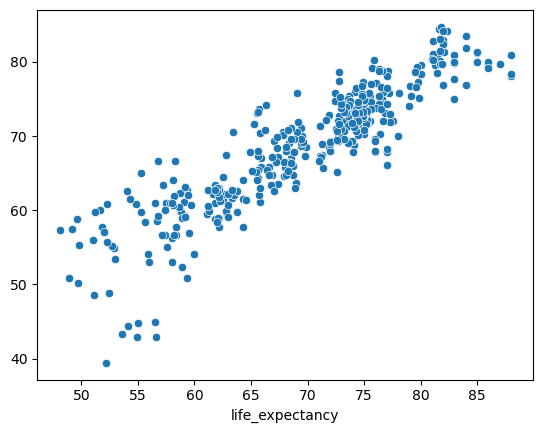

In [24]:
svr = SVR(kernel='poly')

svr.fit(X_train,y_train)
y_pred = svr.predict(X_val)
results.loc['poly-SVR-default', :] = ['poly-2',1,0]+comptue_metrics(y_pred,y_val)

sns.scatterplot(x=y_val, y=y_pred)
results.sort_values(by='R2', ascending=False)

Again, we tune the hyperparameters. We are doing a gridsearch trying 3*3*4 combinations of parameters. This can be slow, but the most parameters we try the best we could fit our data. We will need to find the balance between how much we want to wait to obtain good results. 

In [25]:
cv_results_poly = pd.DataFrame(columns=['Kernel', 'C', 'epsilon', 'R2', 'MSE', 'median_absolute_error', 'mean_absolute_error'])

degrees = [2,3,5]
Cs = [30,40,50]
epsilons = [0.001,0.0001,0.00001,0]
for degree in degrees:
    for c in Cs:
        for epsilon in epsilons:
            svm = SVR(kernel='poly',degree=degree, C=c,epsilon=epsilon)
            svm.fit(X_train,y_train)
            y_pred = svm.predict(X_val)
            cv_results_poly.loc['polySVR-{}-{}-{}'.format(degree,c,epsilon), :] =['poly-{}'.format(degree),c,epsilon] + comptue_metrics(y_pred,y_val)

best = cv_results_poly.sort_values(by='R2',ascending=False).iloc[0,:]
results.loc['polySVR-best',:] = best

results.sort_values(by='R2', ascending=False)

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
RBFSVR-best,RBF,50,0.00001,0.852333,11.763404,2.038311,2.679041
polySVR-best,poly-2,40,0.001,0.850158,12.900961,2.13521,2.764939
LinearSVR-best,linear,60,0,0.815502,15.245514,2.352258,3.01427
LinearSVR-default,linear,1,0,0.812529,15.038759,2.174869,2.972721
KNN,-,-,-,0.811983,13.925304,2.12,2.886305
poly-SVR-default,poly-2,1,0,0.778219,15.10965,2.30372,2.915766
RBF-SVR-default,RBF,1,0,0.772741,13.466168,2.089179,2.818085
SigmoidSVR-best,Sigmoid,60,0.000001,-0.014474,302543.029787,406.042937,451.113992
SigmoidSVR-default,Sigmoid,1,0,-1.496859,179.074224,10.629716,11.235336


The best model until now is the RBF, followed by the polynomical kernel. 

### Custom kernel

One of the more powerful features of SVMs is that you can use a custom kernel. That means that you can addapt completely to your data, whatever shape it has. You could do kernels for mixed data, categorical, text, radio signals, etc. 

To try our custom kernel we will use the same pre-processing than before but including the categorical variables. The other models would not accept categorical data. For this reason we are using them only here.

In [26]:
X_train, y_train, X_val, y_val, X_test, y_test = load_and_split_life_expectancy_data()

def minimum_preprocessing_with_cat(X, y):
    print('Original shape:{}'.format(X.shape))
    categorical_columns = ['status', 'country']
    numerical_columns = [c for c  in X.columns if c not in categorical_columns]
    # We remove missing values
    X=X.dropna()
    y=y[X.index]
    # Normalize
    X[numerical_columns] = minmax_scale(X[numerical_columns])
    print('New shape:{}'.format(X.shape))
    return X, y

X_train, y_train = minimum_preprocessing_with_cat(X_train,y_train)
X_val, y_val = minimum_preprocessing_with_cat(X_val,y_val)
X_test, y_test = minimum_preprocessing_with_cat(X_test,y_test)

Original shape:(1830, 21)
New shape:(999, 21)
Original shape:(549, 21)
New shape:(387, 21)
Original shape:(559, 21)
New shape:(263, 21)


To use a custom kernel you need to make a kernel function and comute its gram matrix. Here we have a simple example of the gaussian kernel modified so it can use the categorical variables. 

We use a simple weight approach to add the categorical columns to our kernel similarity. 

This way we have two new hyperparameters. The weight we will use when the two samples have the same country and the weight we will use when they have the same status. 

In [27]:
def gaussian_kernel(x1, x2, country_weight=0.8, developed_weight=0.6):
    # Ensure that x1 and x2 are column vectors
    index_numerical = [
        False, True, False, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True
    ]
    country_index = 0
    status_index = 2

    x1 = x1[index_numerical].flatten()
    x2 = x2[index_numerical].flatten()

    country_similarity = country_weight if x1[country_index] == x2[
        country_index] else 1 - country_weight
    developed_similarity = developed_weight if x1[status_index] == x2[
        status_index] else 1 - developed_weight

    gamma = 1.0 / len(x1)
    sim = np.exp(-gamma * np.sum(np.power(
        (x1 - x2), 2))) * country_similarity * developed_weight

    return sim


def compute_gram_matrix(X1, X2, country_weight, developed_weight):
    gram_matrix = np.zeros((X1.shape[0], X2.shape[0]))
    for i, x1 in enumerate(X1):
        for j, x2 in enumerate(X2):
            gram_matrix[i, j] = gaussian_kernel(x1, x2, country_weight,
                                                developed_weight)
    return gram_matrix


cv_results_custom = pd.DataFrame(columns=[
    'Kernel','C','epsilon', 'country', 'developed', 'R2', 'MSE', 'median_absolute_error', 'mean_absolute_error'
])

country_weights = [0.6, 0.7, 0.8]
developed_weights = [ 0.7, 0.8, 0.9,0.99]

for c in country_weights:
    for d in developed_weights:
        clf = SVR(C=50, epsilon=0.00001, kernel="precomputed")
        clf.fit(compute_gram_matrix(X_train.values, X_train.values, c, d),
                y_train)
        y_pred = clf.predict(
            compute_gram_matrix(X_val.values, X_train.values, c, d))
        cv_results_custom.loc['custom-{}-{}'.format(c, d), :] = ['custom-{}-{}'.format(c,d),50,0.00001,
            c, d
        ] + comptue_metrics(y_pred, y_val)

We fix the other hyperparameters to focus on these new ones. Ideally we would tune all hyperparameters, but that would be too slow. 

The best parameters we find are 0.6 for the country weight and 0.99 for the developed one. 

In [28]:
cv_results_custom.sort_values(by='R2')

,Kernel,C,epsilon,country,developed,R2,MSE,median_absolute_error,mean_absolute_error
custom-0.8-0.7,custom-0.8-0.7,50,0.00001,0.8,0.7,0.739508,15.645334,2.134522,2.966237
custom-0.8-0.8,custom-0.8-0.8,50,0.00001,0.8,0.8,0.74324,15.773051,2.202148,2.978007
custom-0.8-0.9,custom-0.8-0.9,50,0.00001,0.8,0.9,0.744828,15.873259,2.143111,2.989568
custom-0.8-0.99,custom-0.8-0.99,50,0.00001,0.8,0.99,0.745873,15.905182,2.177444,2.994407
custom-0.7-0.7,custom-0.7-0.7,50,0.00001,0.7,0.7,0.784492,14.252465,2.006082,2.822264
custom-0.7-0.9,custom-0.7-0.9,50,0.00001,0.7,0.9,0.785359,14.494484,2.1026,2.858207
custom-0.7-0.99,custom-0.7-0.99,50,0.00001,0.7,0.99,0.785581,14.497651,2.100759,2.857423
custom-0.7-0.8,custom-0.7-0.8,50,0.00001,0.7,0.8,0.786148,14.349426,2.061988,2.837373
custom-0.6-0.7,custom-0.6-0.7,50,0.00001,0.6,0.7,0.80438,13.802784,2.061898,2.803909
custom-0.6-0.8,custom-0.6-0.8,50,0.00001,0.6,0.8,0.806887,13.683074,2.008241,2.791579


We still don't get better results than the ones we got with the RBF, but we might get better results tunning the hyperparameters further. 

In [29]:
best = cv_results_custom.sort_values(by='R2',ascending=False).iloc[0,:]
results.loc['CustomSVR-best',:] = best
results.sort_values(by='R2',ascending=False)

,Kernel,C,epsilon,R2,MSE,median_absolute_error,mean_absolute_error
RBFSVR-best,RBF,50,0.00001,0.852333,11.763404,2.038311,2.679041
polySVR-best,poly-2,40,0.001,0.850158,12.900961,2.13521,2.764939
LinearSVR-best,linear,60,0,0.815502,15.245514,2.352258,3.01427
LinearSVR-default,linear,1,0,0.812529,15.038759,2.174869,2.972721
KNN,-,-,-,0.811983,13.925304,2.12,2.886305
CustomSVR-best,custom-0.6-0.99,50,0.00001,0.808528,13.681723,2.023096,2.79632
poly-SVR-default,poly-2,1,0,0.778219,15.10965,2.30372,2.915766
RBF-SVR-default,RBF,1,0,0.772741,13.466168,2.089179,2.818085
SigmoidSVR-best,Sigmoid,60,0.000001,-0.014474,302543.029787,406.042937,451.113992
SigmoidSVR-default,Sigmoid,1,0,-1.496859,179.074224,10.629716,11.235336


We have our best model. Now we see how it generalizes. 

In [30]:
X_train, y_train, X_val, y_val, X_test, y_test = load_and_split_life_expectancy_data()

X_train, y_train = minimum_preprocessing(X_train,y_train)
X_val, y_val = minimum_preprocessing(X_val,y_val)
X_test, y_test = minimum_preprocessing(X_test,y_test)

Original shape:(1830, 21)
Droped: ['status', 'country']
New shape:(999, 19)
Original shape:(549, 21)
Droped: ['status', 'country']
New shape:(387, 19)
Original shape:(559, 21)
Droped: ['status', 'country']
New shape:(263, 19)


Our R2 score is significantly lower than the one we obtained with the validation partition. This might be caused by overfitting on the training data with a too complex model or by the representativity of the test data. 

In [31]:
svr = SVR(kernel='rbf',C=50, epsilon=0.000005)
svr.fit(X_train,y_train)
y_pred = svr.predict(X_val)

y_test_pred = svr.predict(X_test)

comptue_metrics(y_test_pred, y_test)

[0.5814175879884798, 32.320546807941916, 4.442030339692479, 4.863984493619384]

## SECTION 2: Labeled Faces in the Wild

We are going to work again with the LFW dataset. This time using different strategies and new metrics. 

This dataset contains images in black and white of public personalities. The task is to clasify the images with the proper name.


### Metrics we will use to validate the results: 

Last time we focussed on Accuracy and Recall. This time we are adding the other metrics that are comonly used on classification problems. 


**Accuracy:**

$$accuracy = \frac{\sum_c tp_c}{n}$$

Where tp_c are the true positive predictions for all the classes and n are the total number of samples. This metric is sensitive to imbalanced data.  

**Precision (of a class):**

$$precission_c = \frac{tp}{tp + fp}$$

Where tp aer the true positives (samples correctly predicted of this class) and fp are the false positives (samples from another class predicted incorrectly as this class). This metric measures how much the model is predicting correctly a class with respect all the predictions of this class. We will use this metric when having false positive predictions is very harmful in our model context. 


**Recall (of a class):**

$$recall_c = =\frac{tp}{tp + fn}$$

Where tp are the true positives (samples correctly predicted of this class) and fn are the false negatives (samples from this class predicted incorrectly as a different class). This metric measures how much the model is predicting correctly a class with respect all the real values of this class. We will use this metric when having false negative predictions is very harmful in our model context.

**F1-score (of a class):**

$$\frac{2 * precission_c * recall_c }{precission_c + recall_c}$$

The harmonic mean of precission and recall. We will use this metric when we want a good balance between precission & recall.  

In [32]:
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
n_samples, h, w = lfw_people.images.shape
X = lfw_people.data
n_features = X.shape[1]

y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]


print("Total dataset size:")
print("n_samples: {}".format(n_samples))
print("n_features: {}".format(n_features))
print("n_classes: {}".format(n_classes))

Total dataset size:
n_samples: 1288
n_features: 1850
n_classes: 7


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

def preprocessing(X_train, X_test):
    X_train = StandardScaler().fit_transform(X_train)
    X_test = StandardScaler().fit_transform(X_test)

    pca = PCA().fit(X_train)

    n_components =(pca.explained_variance_ratio_.cumsum() < 0.99).sum()
    
    pca = PCA(n_components=n_components).fit(X_train)

    X_train_pca = pca.transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    return X_train_pca, X_test_pca


X_train, X_test =  preprocessing(X_train, X_test)

In [34]:
results_df = pd.DataFrame(columns=['Accuracy', 'Recall (mean)','F1-score (mean)', 'Time(s)'])
results_df

,Accuracy,Recall (mean),F1-score (mean),Time(s)


### MLP 

Now we are going to use the best mlp we found on the previous lab. We are using this model instead of a baseline because we already know the problem and already have models that work on it. 

In [35]:
init_time = time()
model_nnet = MLPClassifier(hidden_layer_sizes=[6],
                           alpha=0.1,
                           activation='logistic',
                           max_iter=200,
                           solver='lbfgs',random_state=42)
model_nnet.fit(X_train,y_train);

training_time = time()-init_time
print(timedelta(seconds=training_time))

scores = cross_val_score(model_nnet, X_train, y_train, cv=5)
scores_recall = cross_val_score(model_nnet, X_train, y_train, cv=5,scoring='recall_macro')
scores_f_score = cross_val_score(model_nnet, X_train, y_train, cv=5,scoring='f1_macro')
results_df.loc['MLP',:] = [np.mean(scores),np.mean(scores_recall),np.mean(scores_f_score),training_time]
results_df

0:00:00.278055


,Accuracy,Recall (mean),F1-score (mean),Time(s)
MLP,0.747316,0.681335,0.677574,0.278055


### SVM 


In [36]:
init_time = time()
svm = SVC()
svm.fit(X_train,y_train)

training_time = time()-init_time
print(timedelta(seconds=training_time))

scores = cross_val_score(svm, X_train, y_train, cv=5)
scores_recall = cross_val_score(svm, X_train, y_train, cv=5,scoring='recall_macro')
scores_f_score = cross_val_score(svm, X_train, y_train, cv=5,scoring='f1_macro')
results_df.loc['SVM-default',:] = [np.mean(scores),np.mean(scores_recall),np.mean(scores_f_score),training_time]
results_df

0:00:00.217918


,Accuracy,Recall (mean),F1-score (mean),Time(s)
MLP,0.747316,0.681335,0.677574,0.278055
SVM-default,0.710154,0.551401,0.612542,0.217918


But SVM have an advantage that we can use with unbalanced data. They can weight the C hyperparameter based on the number of samples of each class. Penalyzing this way the majoritary classes. 

In [37]:
init_time = time()
svm = SVC(class_weight='balanced')
svm.fit(X_train,y_train)

training_time = time()-init_time
print(timedelta(seconds=training_time))

scores = cross_val_score(svm, X_train, y_train, cv=5)
scores_recall = cross_val_score(svm, X_train, y_train, cv=5,scoring='recall_macro')
scores_f_score = cross_val_score(svm, X_train, y_train, cv=5,scoring='f1_macro')
results_df.loc['SVM-balanced',:] = [np.mean(scores),np.mean(scores_recall),np.mean(scores_f_score),training_time]
results_df

0:00:00.245988


,Accuracy,Recall (mean),F1-score (mean),Time(s)
MLP,0.747316,0.681335,0.677574,0.278055
SVM-default,0.710154,0.551401,0.612542,0.217918
SVM-balanced,0.771182,0.720652,0.72798,0.245988


Now let's see the effect of tuning the hyperparameters on this model.

In [38]:
init_time = time()

svm = SVC(class_weight='balanced')

kernels = ['linear', 'rbf', 'poly']
Cs = [0.1, 0.001, 0.5, 1, 2, 3, 4, 5, 6, 0.0001]

trc = GridSearchCV(estimator=svm,
                   param_grid={
                       'C': Cs,
                       'kernel': kernels
                   },
                   scoring=['accuracy', 'recall_macro', 'f1_macro'],
                   cv=5,
                   return_train_score=True,
                   refit='f1_macro')

model_5CV = trc.fit(X_train, y_train)
print(timedelta(seconds=(time() - init_time)))

model_5CV.best_score_
model_5CV.best_params_

0:00:41.722902


{'C': 0.001, 'kernel': 'linear'}

The results show that the best kernel for our data is linear and the best C is 0.1

In [39]:
pd.DataFrame(model_5CV.cv_results_).loc[:, [
    'mean_fit_time',
    'std_fit_time',
    'param_C',
    'param_kernel',
    'mean_test_accuracy',
    'std_test_accuracy',
    'mean_test_recall_macro',
    'std_test_recall_macro',
    'mean_test_f1_macro',
    'std_test_f1_macro',
]].sort_values(by='mean_test_f1_macro',ascending=False)

,mean_fit_time,std_fit_time,param_C,param_kernel,mean_test_accuracy,std_test_accuracy,mean_test_recall_macro,std_test_recall_macro,mean_test_f1_macro,std_test_f1_macro
3,0.096831,0.000619,0.001,linear,0.823973,0.034068,0.821202,0.037680,0.796933,0.041998
0,0.088071,0.002125,0.1,linear,0.821938,0.011747,0.791983,0.025500,0.791859,0.022986
9,0.086076,0.002357,1,linear,0.821938,0.011747,0.791983,0.025500,0.791859,0.022986
24,0.086053,0.002313,6,linear,0.821938,0.011747,0.791983,0.025500,0.791859,0.022986
21,0.086105,0.002211,5,linear,0.821938,0.011747,0.791983,0.025500,0.791859,0.022986
18,0.086031,0.002161,4,linear,0.821938,0.011747,0.791983,0.025500,0.791859,0.022986
12,0.086101,0.002382,2,linear,0.821938,0.011747,0.791983,0.025500,0.791859,0.022986
15,0.086172,0.001943,3,linear,0.821938,0.011747,0.791983,0.025500,0.791859,0.022986
6,0.087166,0.002180,0.5,linear,0.821938,0.011747,0.791983,0.025500,0.791859,0.022986
13,0.152398,0.000902,2,rbf,0.797067,0.033333,0.727290,0.045190,0.752530,0.037814


In [40]:
model_5CV.best_score_

0.7969333549025602

We now have our best model. We can re-train it and see if it generalizes properly using the test set.

In [41]:
init_time = time()
svm = SVC(kernel='linear',class_weight='balanced', C=0.1)
svm.fit(X_train,y_train)

training_time = time()-init_time
print(timedelta(seconds=training_time))

scores = cross_val_score(svm, X_train, y_train, cv=5)
scores_recall = cross_val_score(svm, X_train, y_train, cv=5,scoring='recall_macro')
scores_f_score = cross_val_score(svm, X_train, y_train, cv=5,scoring='f1_macro')
results_df.loc['SVM-best',:] = [np.mean(scores),np.mean(scores_recall),np.mean(scores_f_score),training_time]
results_df

0:00:00.128817


,Accuracy,Recall (mean),F1-score (mean),Time(s)
MLP,0.747316,0.681335,0.677574,0.278055
SVM-default,0.710154,0.551401,0.612542,0.217918
SVM-balanced,0.771182,0.720652,0.72798,0.245988
SVM-best,0.821938,0.791983,0.791859,0.128817


We obtain good results on the test set again. 

In [42]:
y_pred = svm.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.53      0.77      0.62        13
           1       0.80      0.85      0.82        60
           2       0.60      0.67      0.63        27
           3       0.94      0.88      0.91       146
           4       0.74      0.80      0.77        25
           5       0.71      0.67      0.69        15
           6       0.84      0.75      0.79        36

    accuracy                           0.82       322
   macro avg       0.74      0.77      0.75       322
weighted avg       0.83      0.82      0.82       322



# Annex: Correlation metrics computation

### Pearson's R for continuous-continuous cases

Pearson will compute a correlation coeficient based on covariance between variables. ([wikipedia](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient))

$$
pearson_{X,Y} = \frac{cov(X,Y)}{\sigma_X \sigma_Y}
$$



In [43]:
life_expectancy_data[['country','adult_mortality', 'life_expectancy','status']].isna().sum()

country             0
adult_mortality    10
life_expectancy    10
status              0
dtype: int64

In [44]:
life_expectancy_data = life_expectancy_data[['country','adult_mortality', 'life_expectancy','status']].dropna()
adult_mortality = life_expectancy_data['adult_mortality']
life_expectancy = life_expectancy_data['life_expectancy']


covariance_matrix = np.cov(adult_mortality,life_expectancy)
cov_xy = covariance_matrix[0,1]
var_x = covariance_matrix[0,0]
var_y = covariance_matrix[1,1] 

covariance_matrix

array([[15448.52090299,  -824.30927254],
       [ -824.30927254,    90.70405193]])

In [45]:
pearson = cov_xy/np.sqrt(var_x*var_y)
pearson

-0.6963593137699758

In [46]:
life_expectancy_data = life_expectancy_data[['country','adult_mortality', 'life_expectancy','status']].dropna()
adult_mortality = life_expectancy_data['adult_mortality']
life_expectancy = life_expectancy_data['life_expectancy']


covariance_matrix = np.cov(adult_mortality,life_expectancy)
cov_xy = covariance_matrix[0,1]
var_x = covariance_matrix[0,0]
var_y = covariance_matrix[1,1] 

covariance_matrix

array([[15448.52090299,  -824.30927254],
       [ -824.30927254,    90.70405193]])

In [47]:
pearson = cov_xy/np.sqrt(var_x*var_y)
pearson

-0.6963593137699758

In [48]:
pearsonr(adult_mortality,life_expectancy)

PearsonRResult(statistic=-0.696359313769976, pvalue=0.0)

### Correlation Ratio for categorical-continuous cases
([wikipedia](https://en.wikipedia.org/wiki/Correlation_ratio))

Suppose each observation is $y_{xi}$ where x indicates the category that observation is in and i is the label of the particular observation. Let nx be the number of observations in category x and

$
\overline {y}_{x}={\frac  {\sum _{i}y_{{xi}}}{n_{x}}}
$
and 
$
\overline {y}={\frac  {\sum _{x}n_{x}\overline {y}_{x}}{\sum _{x}n_{x}}}
$,

where ${\overline {y}}$ is the mean of the whole population. The correlation ratio η (eta) is defined as to satisfy

$$\eta ^{2}={\frac  {\sum _{x}n_{x}(\overline {y}_{x}-\overline {y})^{2}}{\sum _{{x,i}}(y_{{xi}}-\overline {y})^{2}}}$$


In [49]:
country_life_expectancy = life_expectancy_data[['country','life_expectancy']]

categories = country_life_expectancy['country'].unique()

y_x_all = []
n_x_all = []
for category in categories:
    category_index = country_life_expectancy['country'] == category
    n_x = category_index.sum()
    y_x_i = country_life_expectancy.loc[category_index,'life_expectancy']
    y_x = np.average(y_x_i)
    
    y_x_all.append(y_x)
    n_x_all.append(n_x)

    
y_bar = np.dot(n_x_all,y_x_all)/np.sum(n_x_all)

correlation_coef = np.sqrt(np.dot(n_x_all,(y_x_all - y_bar)**2)/ np.sum((country_life_expectancy['life_expectancy'].values-y_bar)**2))
correlation_coef

0.9620947216514733

In [50]:
correlation_ratio(life_expectancy_data['country'],life_expectancy_data['life_expectancy'])

0.9620947216514734

### Cramer's V for categorical-categorical cases 

Cramer's V will compute correlation based on coocurrence.([wikipedia](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V))

$n_{i,j}$= number of times the values $ (A_{i},B_{j})$ were observed.

Chi-squared statistic: 

$$
\chi^2 = \sum_{ij} \frac{(n_{ij}- \frac{n_i n_j}{n})^2}{\frac{n_in_j}{n}}
$$

* $\varphi = \frac{\chi^2}{n}$ 
* $n$ is the grand total of observations and
* $k$ being the number of columns.
* $r$ being the number of rows.

Cramer V: 

$$ V = \sqrt{\frac{\varphi^2}{min(k-1,r-1)}}$$

`dython` library uses the corrected version of Cramer V: 
$$
\tilde{V}={\sqrt {\frac {{\tilde {\varphi }}^{2}}{\min({\tilde {k}}-1,{\tilde {r}}-1)}}}
$$
where

$$
 {\tilde {\varphi }}^{2}=max \left(0,\varphi ^{2}-{\frac {(k-1)(r-1)}{n-1}}\right) 
$$
and
$$
 {\tilde {k}}=k-{\frac {(k-1)^{2}}{n-1}}
$$
$$
{\tilde {r}}=r-{\frac {(r-1)^{2}}{n-1}}
$$

In [51]:
crosstab= pd.crosstab(life_expectancy_data['country'],life_expectancy_data['status'])

chi2 = chi2_contingency(crosstab)[0]
n = crosstab.sum().sum()
phi2 = chi2/n
r,k = crosstab.shape

cramer_v = np.sqrt(phi2/(np.min([k-1,r-1])))
cramer_v

1.0

In [52]:
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)

corrected_cramer_v=np.sqrt(phi2corr / min( (kcorr-1), (rcorr-1)))
corrected_cramer_v

0.9685766911101358

In [53]:
cramers_v(life_expectancy_data['country'],life_expectancy_data['status'])

0.9685766911101358